# Module 2: Data Preprocessing and Feature Engineering  
This notebook transforms raw data into **predictive features**.  
The main focus is on applying **Cross-Sectional Ranking** to normalize data across different stocks at the same point in time.

> **Environment Note:** This notebook was developed and tested on a **Linux-based environment**. If you are running it on Windows, some file paths (e.g., `src/features.py`) may need to use backslashes, and shell commands prefixed with `!` may not work as expected. Consider using [WSL](https://learn.microsoft.com/en-us/windows/wsl/) or running it inside a Linux container for the smoothest experience.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import sklearn
import time
import os
import sys
import seaborn as sns

project_root = os.path.abspath("/kaggle/input/datasets/phmhuyphongp/modules-vn100")

if project_root not in sys.path:
    sys.path.append(project_root)

import src.features as ft
import src.evaluation as ev
import src.models as md 
import src.feature_search as fs

In [2]:

FILE_URL = "/kaggle/input/datasets/phmhuyphongp/vn100-project/market_data.parquet"
df = pd.read_parquet(FILE_URL)
df = df[df["close"] > 0]
df.head()

,date,open,high,low,close,volume,Symbol
0,2017-08-08,4.63,4.65,4.55,4.56,382940,ACB
1,2017-08-09,4.56,4.56,4.46,4.49,1649412,ACB
2,2017-08-10,4.46,4.51,4.44,4.46,1139760,ACB
3,2017-08-11,4.48,4.48,4.44,4.46,774623,ACB
4,2017-08-14,4.44,4.51,4.44,4.51,657975,ACB


## 2.1 Feature Selection Rationale
In this project, I select 8 primary features categorized into three groups to capture the Vietnamese stock market's dynamics:

* **Momentum Indicators**: `log_ret_1m`, `log_ret_3m`, `log_ret_1y` - These capture the trend-following behavior of investors.
* **Risk & Volatility**: `volatility_3m`, `volatility_shock_monthly` - These measure the systematic and unsystematic risk levels.
* **Trend & Liquidity**: `dist_SMA_100`, `RSI_14`, `volume_surge_monthly` - These identify overbought/oversold conditions and abnormal trading interest.

### Cross-Sectional Ranking
Instead of using absolute values, I apply **Cross-Sectional Ranking** to every feature. This technique normalizes data across 100 tickers at each timestamp, effectively removing "Market Beta" and focusing on the relative strength (Alpha) of each stock within the VN100 basket.

In [3]:
# Define your features and target
features = [
    'log_ret_1m', 'log_ret_3m', 'log_ret_1y',
    'volatility_shock_monthly', 'volatility_3m',
    'dist_SMA_100', 'RSI_14', 'volume_surge_monthly'
]

In [4]:
df = ft.build_features(df)
df = ft.target_generating_ranking(df)
#df,new_features = ft.apply_cross_sectional_ranking(df,features)
#features = features + new_features

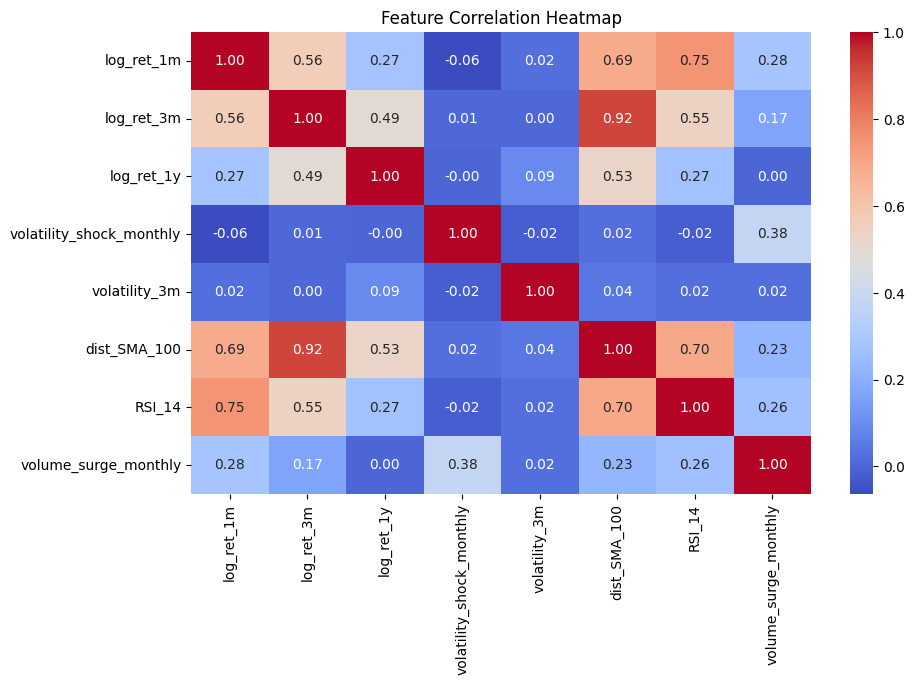

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
best_features, best_roi, results_df = fs.find_best_feature_combo(
    df,
    initial_capital=10_000,
    walk_forward_kwargs=dict(initial_train_months=24, test_months=6, gap_days=21),
    backtest_kwargs=dict(buy_fraction=0.05, hold_fraction=0.15,
                         trend_filter_col='dist_SMA_100'),
)


Feature-Combo Search: 31 combinations to evaluate
Groups: ['returns', 'volatility', 'moving_average', 'volume', 'rsi']

[1/31] Testing: returns
         Features (5): ['log_ret_1w', 'log_ret_1m', 'log_ret_3m', 'log_ret_6m', 'log_ret_1y']
Fold 1/11 (2020-08): NDCG = 0.8359
Fold 2/11 (2021-02): NDCG = 0.8474
Fold 3/11 (2021-08): NDCG = 0.8151
Fold 4/11 (2022-02): NDCG = 0.8354
Fold 5/11 (2022-08): NDCG = 0.8238
Fold 6/11 (2023-02): NDCG = 0.8233
Fold 7/11 (2023-08): NDCG = 0.8299
Fold 8/11 (2024-02): NDCG = 0.8355
Fold 9/11 (2024-08): NDCG = 0.8193
Fold 10/11 (2025-02): NDCG = 0.8536
Fold 11/11 (2025-08): NDCG = 0.8144
Fold 12/11 (2026-02): NDCG = 0.8213

✅ Hoàn thành Walk-forward CV.
         → Final ROI: +117.92%

  🏆 New best! ROI = +117.92%  [returns]

[2/31] Testing: volatility
         Features (7): ['log_ret_daily', 'volatility_1w', 'volatility_1m', 'volatility_3m', 'volatility_6m', 'volatility_shock_monthly', 'volatility_shock_weekly']
Fold 1/11 (2020-08): NDCG = 0.8225
Fold 2/1